In [36]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [37]:
# read case
print(os.getcwd())
case = os.getcwd().split("\\")[-1]
print(case[0])

D:\Promotion\neurolib\GUI\gui\data\00001
0


### Bistability

In [38]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

152


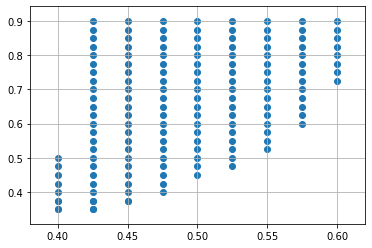

In [39]:
##### LOAD BOUNDARIES
data_file = 'bi_' + case + '.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
plt.scatter(exc, inh)

In [40]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [41]:
dur = 100
dur_pre = 10
dur_post = 10

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[2] == '0':
    cntrl_vars_0 = [0,1]
elif case[2] == '1':
    cntrl_vars_0 = [2,3,4,5]
    
if case[3] == '0':
    maxC = [5., -5., 0.18, 0.]
elif case[3] == '1':
    maxC = [500., -500., 18., 0.]
    
if case[4] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[4] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[4] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[4] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

prec_vars = [0]
trans_time = 0.8
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [7]:
init_file = 'control_init_' + case + '.pickle'

if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    costnode_init = load_array[1]
    weights_init = load_array[2]

In [42]:
i_range = range(0, len(exc),10)
i_range_ = []

for i in i_range:
    print(i, type(bestControl_init[i]))
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

0 <class 'NoneType'>
10 <class 'NoneType'>
20 <class 'NoneType'>
30 <class 'NoneType'>
40 <class 'NoneType'>
50 <class 'NoneType'>
60 <class 'NoneType'>
70 <class 'NoneType'>
80 <class 'NoneType'>
90 <class 'NoneType'>
100 <class 'NoneType'>
110 <class 'NoneType'>
120 <class 'NoneType'>
130 <class 'NoneType'>
140 <class 'NoneType'>
150 <class 'NoneType'>
[  0  10  20  30  40  50  60  70  80  90 100 110 120 130 140 150]


In [43]:
factor_iteration = 10

prev_i = -1
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    # set low state rates as target
    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i])
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    weights_init[i] = cost.getParams()

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]
    
##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    if prev_i != -1:
        control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5309.807227326851
Gradient descend method:  None
RUN  0 , total integrated cost =  5309.807227326851
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5309.807227326851
Gradient descend method:  HS
RUN  1 , total integrated cost =  1217.1004646667843
RUN  2 , total integrated cost =  1195.3101711644583
RUN  3 , total integrated cost =  458.85951819984865
RUN  4 , total integrated cost =  104.12859321911824
RUN  5 , total integrated cost =  43.23843450419199
RUN  6 , total integrated cost =  19.183442327492873
RUN  7 , total integrated cost =  17.510512013708425
RUN  8 , total integrated cost =  15.011130560718822
RUN  9 , total integrated cost =  14.645882703280556
RUN  10 , total integrated cost =  14.358802331353042
RUN 

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  29 , total integrated cost =  13.68573760743833
Improved over  29  iterations in  0.8089584000008472  seconds by  99.74225547140384  percent.
Problem in initial value trasfer:  Vmean_exc -56.62760980180291 -56.6276092776125
weight =  3879.8107779305365
set cost params:  1.0 0.0 3879.8107779305365
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5288.35555508514
Gradient descend method:  None
RUN  1 , total integrated cost =  4783.024949016204
RUN  2 , total integrated cost =  4780.73093737164
RUN  3 , total integrated cost =  4743.44343151912
RUN  4 , total integrated cost =  4736.385775877437
RUN  5 , total integrated cost =  4736.153489646548
RUN  6 , total integrated cost =  4736.038766470611
RUN  7 , total integrated cost =  4735.822599680763
RUN  8 , total integrated cost =  4596.441788359225
RUN  9 , total integrated cost =  4593.523907655641
RUN  10 , total integrated cost =  4549.570169234961
RUN  11 , total integrate

ERROR:root:Problem in initial value trasfer


RUN  50 , total integrated cost =  4528.883580205629
Control only changes marginally.
RUN  54 , total integrated cost =  4528.883580205612
Improved over  54  iterations in  1.2808545000007143  seconds by  14.36121242168069  percent.
Problem in initial value trasfer:  Vmean_exc -56.62596697520683 -56.62596766008164
-------  10 0.4000000000000001 0.40000000000000013
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  4585.52396632752
Gradient descend method:  None
RUN  0 , total integrated cost =  4585.52396632752
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  4590.581026159318
Gradient descend method:  HS
RUN  1 , total integrated cost =  585.2729308526349
RUN  2 , total integrated cost =  584.480448613622
RUN  3 , total integrated cost =  111.67675586830869
RUN  4 , total integrated cost =  82.84910650887737
RUN  5 , t

...

RUN  50 , total integrated cost =  109.7790572522392
Control only changes marginally.
RUN  51 , total integrated cost =  109.7790572522392
Improved over  51  iterations in  1.362176200000249  seconds by  13.426818522489569  percent.
Problem in initial value trasfer:  Vmean_exc -56.70067761236054 -56.70067759409557
weight =  1928.415984602229
set cost params:  1.0 0.0 1928.415984602229
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21162.099198631582
Gradient descend method:  None
RUN  1 , total integrated cost =  21134.22192202726
RUN  2 , total integrated cost =  21133.779818703657
RUN  3 , total integrated cost =  21133.737908278352
RUN  4 , total integrated cost =  21133.736053841476
RUN  5 , total integrated cost =  21133.73567921057
RUN  6 , total integrated cost =  21133.735569857832
RUN  7 , total integrated cost =  21133.73551740757
RUN  8 , total integrated cost =  21133.735502969976
RUN  9 , total integrated cost =  21133.73548655884
RUN  10 , total i

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  49 , total integrated cost =  21132.609496786
Improved over  49  iterations in  1.511539700000867  seconds by  0.13935149612892417  percent.
Problem in initial value trasfer:  Vmean_exc -56.70067500905905 -56.70067508178995
-------  150 0.5750000000000002 0.9000000000000006
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  29947.74360232096
Gradient descend method:  None
RUN  0 , total integrated cost =  29947.74360232096
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  109.56142035139823
Gradient descend method:  HS
RUN  1 , total integrated cost =  95.49243380176374
RUN  2 , total integrated cost =  95.49243380176374
Control only changes marginally.
RUN  2 , total integrated cost =  95.49243380176374
Improved over  2  iterations in  0.10749109999960638  seconds by  12.84118671016

ERROR:root:Problem in initial value trasfer


RUN  190 , total integrated cost =  27894.55870059934
Control only changes marginally.
RUN  190 , total integrated cost =  27894.55870059934
Improved over  190  iterations in  5.940534800000023  seconds by  6.852543880620715  percent.
Problem in initial value trasfer:  Vmean_exc -56.70354230056722 -56.70354228588324


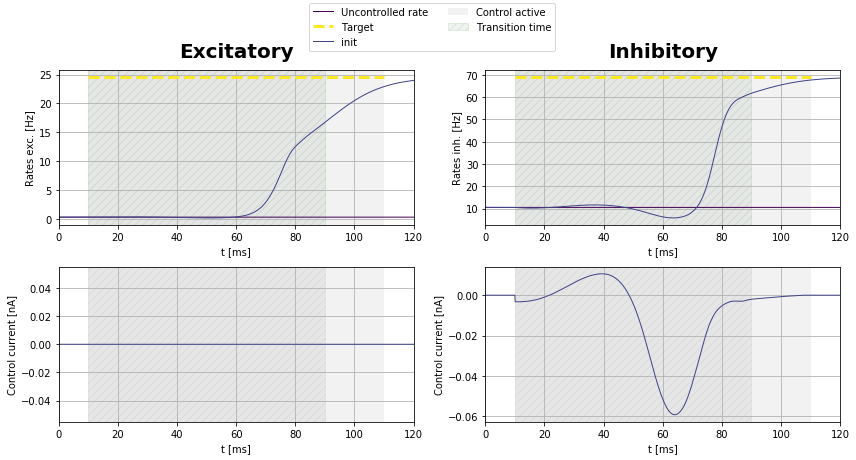

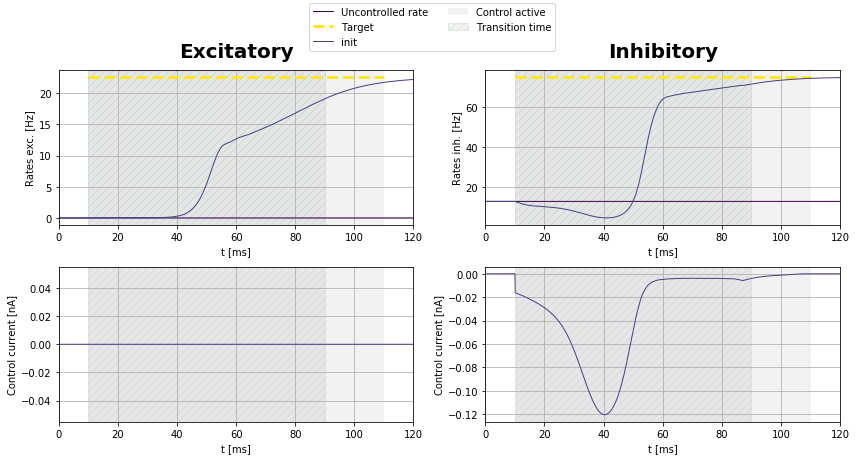

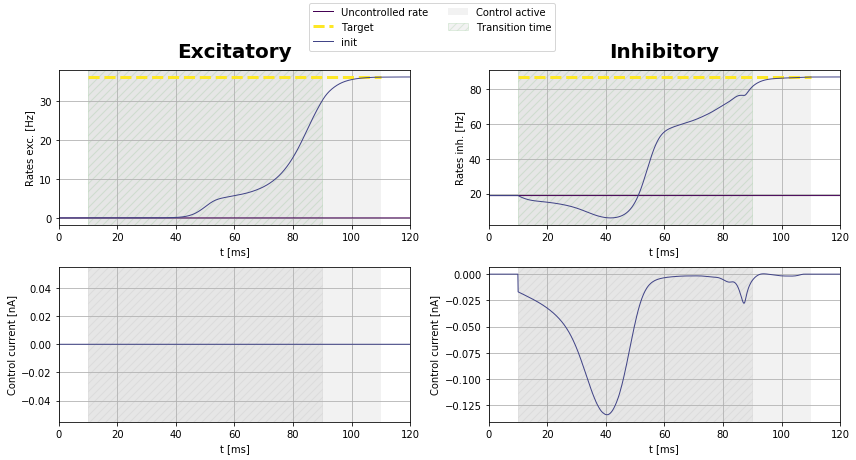

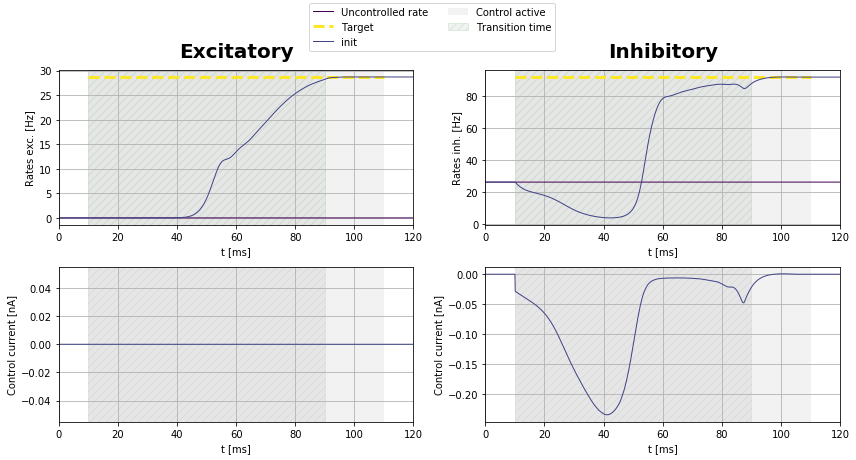

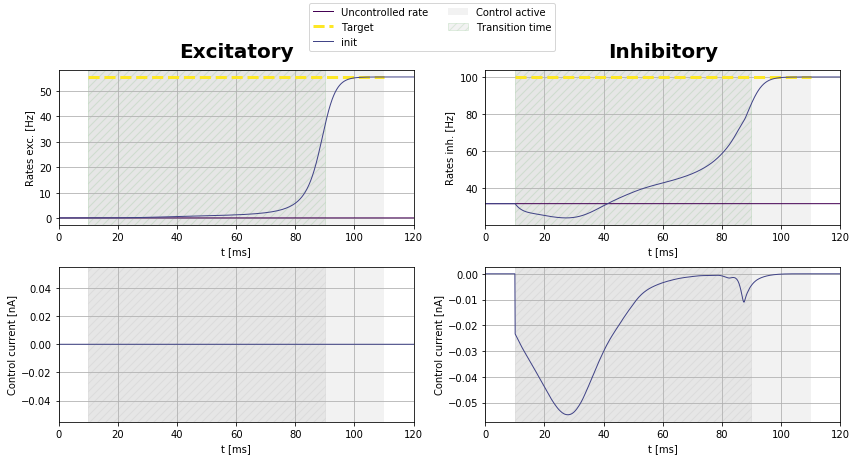

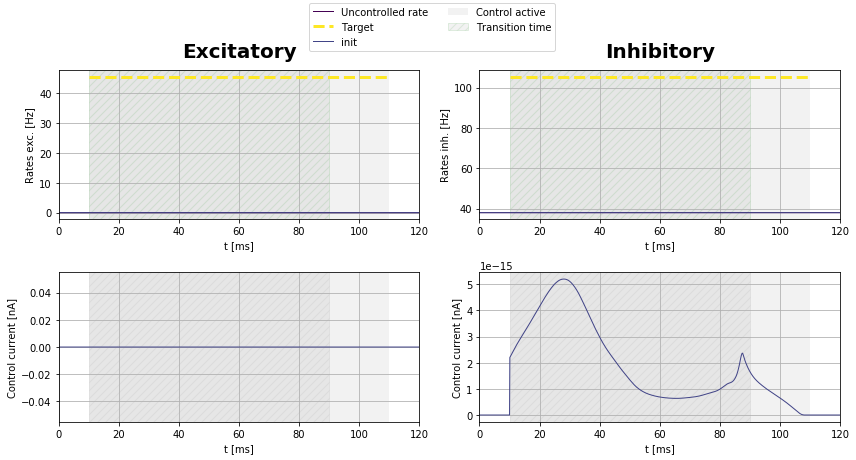

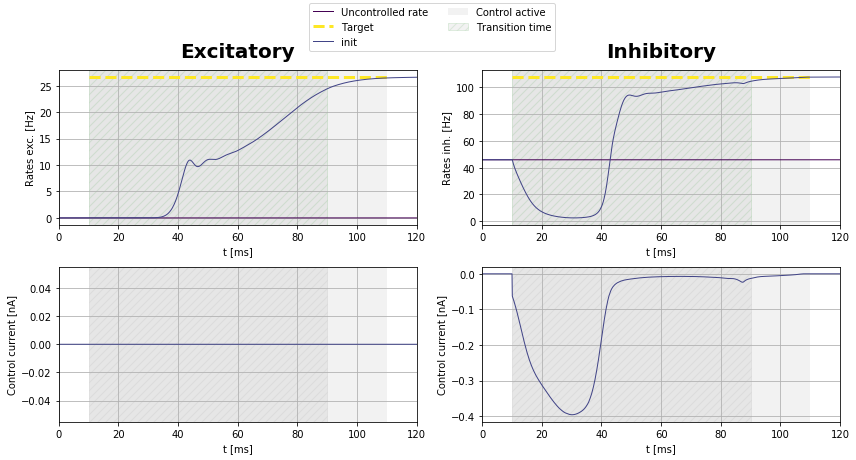

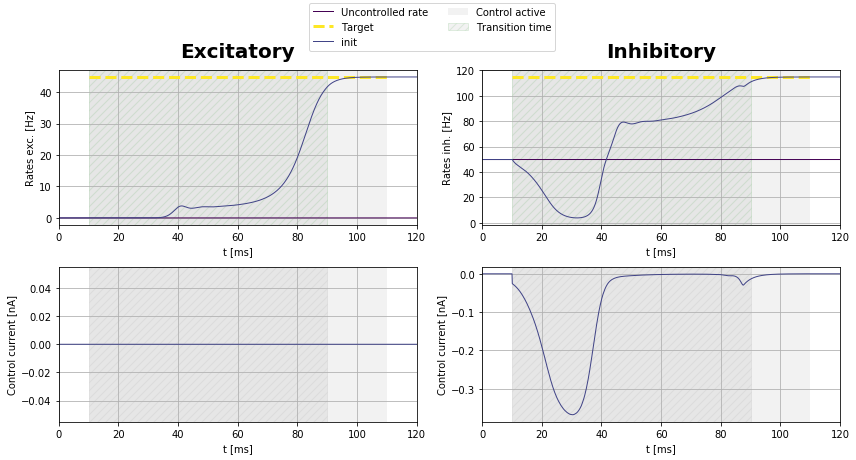

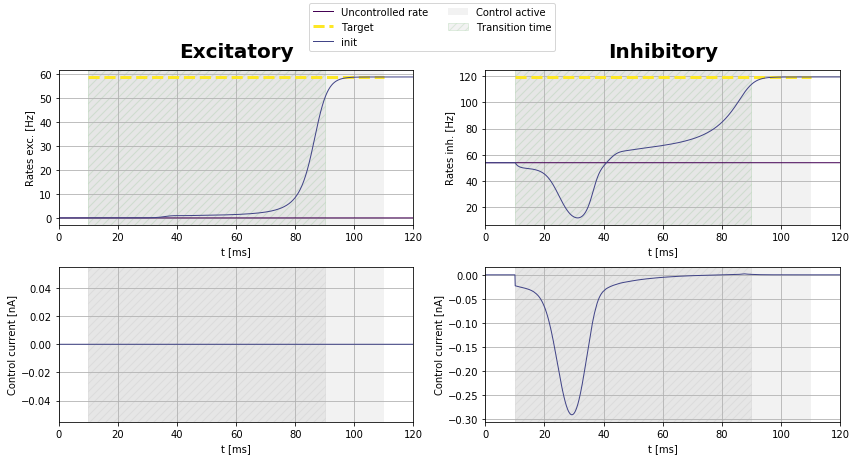

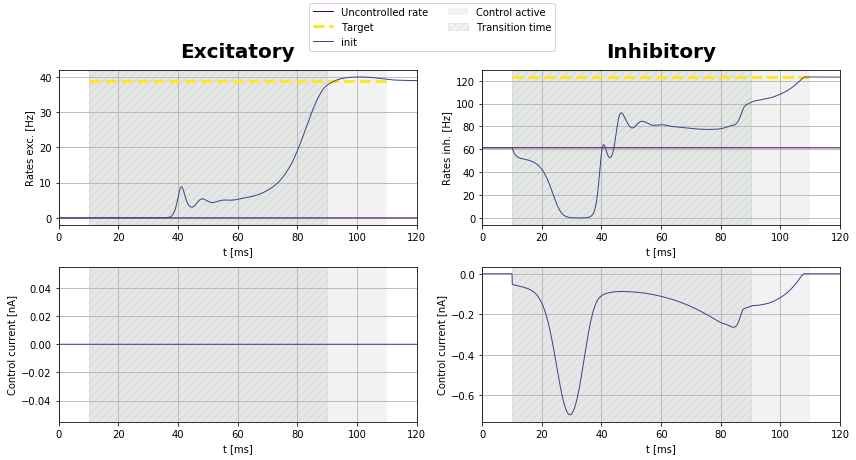

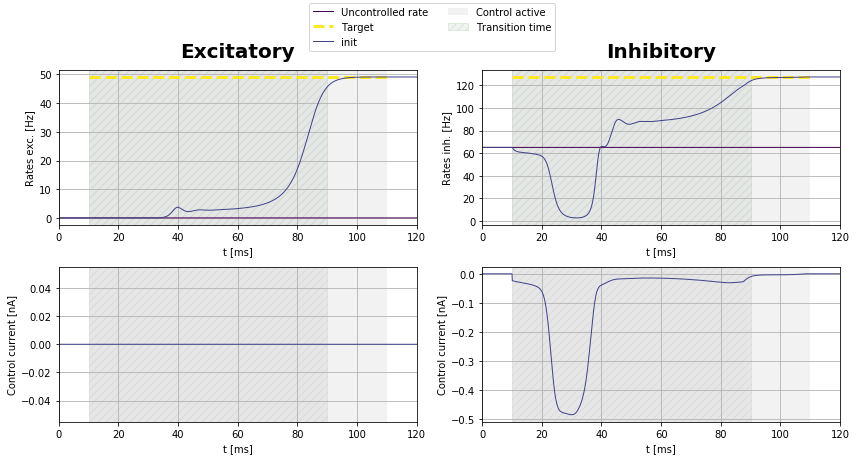

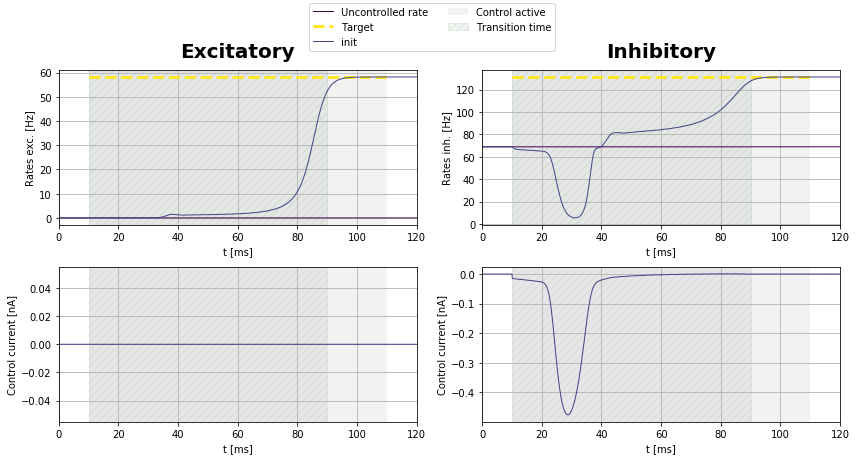

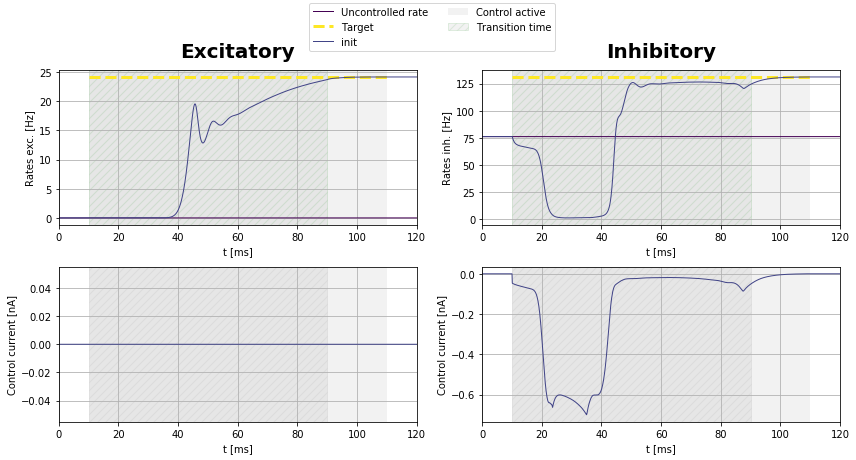

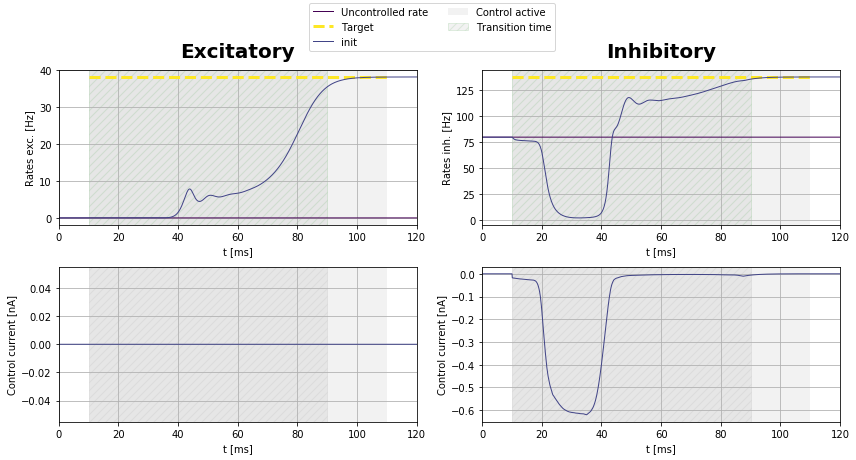

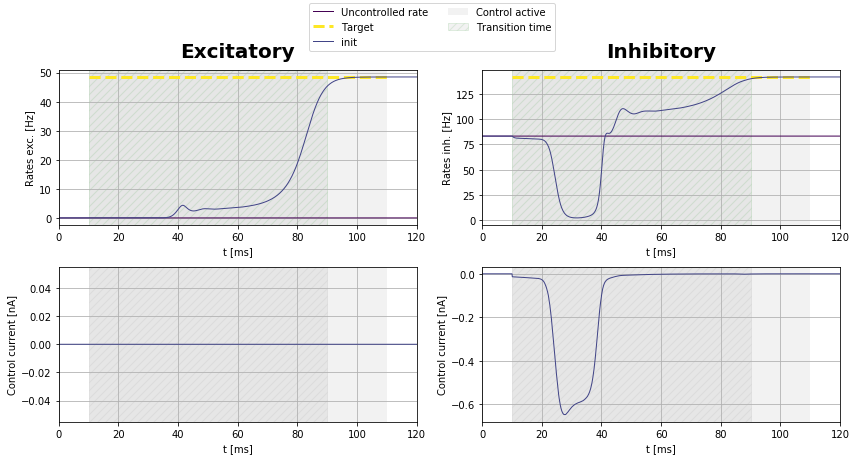

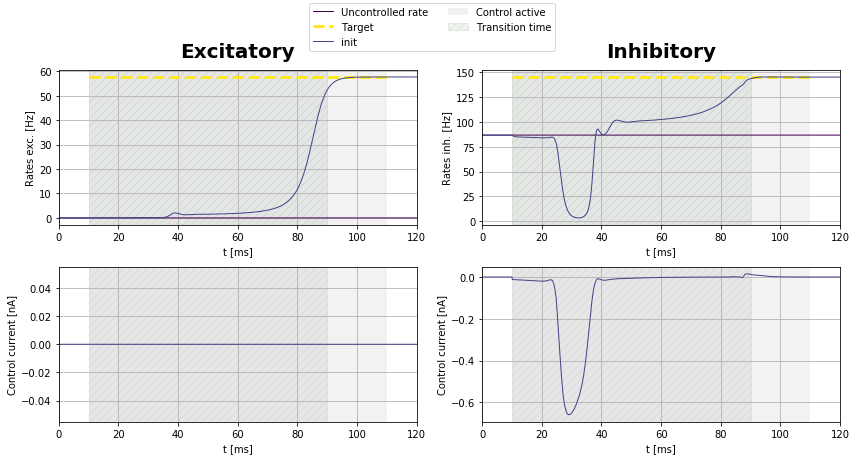

In [10]:
#plot initial guesses

for i in i_range:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [50]:
for k in range(1):

    factor_iteration = 10

    for i in i_range:
        
        #if i not in [174]:
        #    continue
        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i])
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


-------  0 0.4000000000000001 0.3500000000000001
weight =  4588.995971379673
set cost params:  1.0 0.0 4588.995971379673
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5267.031187248452
Gradient descend method:  None
RUN  1 , total integrated cost =  5308.65038128674
Control only changes marginally.
RUN  1 , total integrated cost =  5308.65038128674
Improved over  1  iterations in  0.06890610000118613  seconds by  -0.7901831707214768  percent.
Problem in initial value trasfer:  Vmean_exc -56.625957339141195 -56.62595724765936
-------  10 0.4000000000000001 0.40000000000000013
weight =  1853.747510442726
set cost params:  1.0 0.0 1853.747510442726
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  4572.7669630886685
Gradient descend method:  None
RUN  1 , total integrated cost =  4583.051649234941
Control only changes marginally.
RUN  1 , total integrated cost =  4583.051649234941
Improved over  1  iterations in  0.06640129999868805  seconds

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  11708.401921276842
Control only changes marginally.
RUN  1 , total integrated cost =  11708.401921276842
Improved over  1  iterations in  0.07585000000108266  seconds by  -0.16095426017690784  percent.
Problem in initial value trasfer:  Vmean_exc -56.67025081167898 -56.670261116409336
-------  30 0.4250000000000001 0.5000000000000002
weight =  1466.001531315552
set cost params:  1.0 0.0 1466.001531315552
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7391.936493726708
Gradient descend method:  None
RUN  1 , total integrated cost =  7400.379023660084
Control only changes marginally.
RUN  1 , total integrated cost =  7400.379023660084
Improved over  1  iterations in  0.06750920000195038  seconds by  -0.11421269569267167  percent.
Problem in initial value trasfer:  Vmean_exc -56.63843040620475 -56.63845021970176
-------  40 0.5500000000000003 0.5250000000000002
weight =  21783.624379880963
set cost params:  1.0 0.0 21783.624379880

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


...

RUN  0 , total integrated cost =  21696.56689553042
Gradient descend method:  None
RUN  1 , total integrated cost =  21697.74167898199
Control only changes marginally.
RUN  1 , total integrated cost =  21697.74167898199
Improved over  1  iterations in  0.07000609999886365  seconds by  -0.005414605256333971  percent.
Problem in initial value trasfer:  Vmean_exc -56.70140697065659 -56.7014070429219
-------  110 0.5750000000000002 0.7750000000000005
weight =  4700.385833684403
set cost params:  1.0 0.0 4700.385833684403
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  30478.329787771832
Gradient descend method:  None
RUN  1 , total integrated cost =  30481.91767014434
Control only changes marginally.
RUN  1 , total integrated cost =  30481.91767014434
Improved over  1  iterations in  0.06828450000102748  seconds by  -0.011771912691699526  percent.
Problem in initial value trasfer:  Vmean_exc -56.70334379090593 -56.70334377425246
-------  120 0.4250000000000001 0.825

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  5244.0567009006445
Control only changes marginally.
RUN  1 , total integrated cost =  5244.0567009006445
Improved over  1  iterations in  0.07402219999858062  seconds by  -0.0271217555182659  percent.
Problem in initial value trasfer:  Vmean_exc -56.6236996060987 -56.62370376895042
-------  130 0.47500000000000014 0.8500000000000005
weight =  1030.667737142435
set cost params:  1.0 0.0 1030.667737142435
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13073.605140087753
Gradient descend method:  None
RUN  1 , total integrated cost =  13074.682118605448
Control only changes marginally.
RUN  1 , total integrated cost =  13074.682118605448
Improved over  1  iterations in  0.07581299999947078  seconds by  -0.008237808210935782  percent.
Problem in initial value trasfer:  Vmean_exc -56.677231620543 -56.677233203388276
-------  140 0.5250000000000001 0.8750000000000006
weight =  1930.8258438948938
set cost params:  1.0 0.0 1930.8258438

ERROR:root:Problem in initial value trasfer


RUN  0 , total integrated cost =  29936.15053533795
Gradient descend method:  None
RUN  1 , total integrated cost =  29938.849356541665
Control only changes marginally.
RUN  1 , total integrated cost =  29938.849356541665
Improved over  1  iterations in  0.0708654000009119  seconds by  -0.009015257992260217  percent.
Problem in initial value trasfer:  Vmean_exc -56.70354230056722 -56.70354228588324


In [51]:
with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, costnode_init, weights_init], f)

In [18]:
final_file = 'control_0_' + case + '.pickle'

if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    costnode_0 = load_array[1]
    weights_0 = load_array[2]

In [ ]:
cntrl_vars_0 = c_var[2]

factor_iteration = 10
    
for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i])
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  265.2699505402654
Gradient descend method:  None
RUN  1 , total integrated cost =  13.48086224451212
RUN  2 , total integrated cost =  13.457762643384173
RUN  3 , total integrated cost =  13.455111650928536
RUN  4 , total integrated cost =  13.452664061276499
RUN  5 , total integrated cost =  13.450135656797027
RUN  6 , total integrated cost =  13.44431448546091
RUN  7 , total integrated cost =  13.443642280300429
RUN  8 , total integrated cost =  13.442560610483389
RUN  9 , total integrated cost =  13.44147978202445
RUN  10 , total integrated cost =  13.440905214125046
RUN  11 , total integrated cost =  13.43940945369293
RUN  12 , total integrated cost =  13.438364147642186
RUN  13 , total integrated cost =  13.432019523619484
RUN  14 , total integrated cost =  13.426465810168116
RUN  15 , total integrated cost =  13.41683084935401
RUN

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  65 , total integrated cost =  13.404763681714245
Improved over  65  iterations in  4.18414870000197  seconds by  94.94674626567644  percent.
Problem in initial value trasfer:  Vmean_exc -56.62762636633966 -56.62762626693387
weight =  100
set cost params:  1.0 0.0 100.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  133.6123292529596
Gradient descend method:  HS
RUN  1 , total integrated cost =  131.8590100889343
RUN  2 , total integrated cost =  131.35850580872875
RUN  3 , total integrated cost =  131.35005243598334
RUN  4 , total integrated cost =  131.34750499679606
RUN  5 , total integrated cost =  131.347504996796


ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  131.347504996796
Control only changes marginally.
RUN  6 , total integrated cost =  131.347504996796
Improved over  6  iterations in  0.47237739999764017  seconds by  1.6950713072861276  percent.
Problem in initial value trasfer:  Vmean_exc -56.627608831116724 -56.62760794879847
weight =  4041.5642096942565
set cost params:  1.0 0.0 4041.5642096942565
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5228.749359243447
Gradient descend method:  None
RUN  1 , total integrated cost =  4698.223607174358
RUN  2 , total integrated cost =  4696.032757472949
RUN  3 , total integrated cost =  4695.326904333302
RUN  4 , total integrated cost =  4688.536995406408
RUN  5 , total integrated cost =  4674.303459312227
RUN  6 , total integrated cost =  4673.729291898647
RUN  7 , total integrated cost =  4673.658000247909
RUN  8 , total integrated cost =  4673.630510462301
RUN  9 , total integrated cost =  4673.624089191046
RUN  10 , total integra

...

RUN  30 , total integrated cost =  679.8093265166093
Control only changes marginally.
RUN  31 , total integrated cost =  679.8093265166093
Improved over  31  iterations in  2.3958038999990094  seconds by  0.5462777274598238  percent.
Problem in initial value trasfer:  Vmean_exc -56.69518277230641 -56.69518279863516
weight =  2655.036402030403
set cost params:  1.0 0.0 2655.036402030403
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  18040.88986637265
Gradient descend method:  None
RUN  1 , total integrated cost =  18025.315558916576
RUN  2 , total integrated cost =  18025.309349555228
RUN  3 , total integrated cost =  18025.30934821534
RUN  4 , total integrated cost =  18025.30934821351
RUN  5 , total integrated cost =  18025.309348213475
RUN  6 , total integrated cost =  18025.30934821347


ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  18025.30934821347
Control only changes marginally.
RUN  7 , total integrated cost =  18025.30934821347
Improved over  7  iterations in  1.115249499998754  seconds by  0.08636224861736252  percent.
Problem in initial value trasfer:  Vmean_exc -56.695176036079864 -56.69517627758344
-------  80 0.5750000000000002 0.6750000000000004
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  75.28740572653754
Gradient descend method:  None
RUN  1 , total integrated cost =  43.888154053184586
RUN  2 , total integrated cost =  43.82413753961123
RUN  3 , total integrated cost =  43.80971523009319
RUN  4 , total integrated cost =  43.805704672092894
RUN  5 , total integrated cost =  43.79542675897081
RUN  6 , total integrated cost =  43.79206916219693
RUN  7 , total integrated cost =  43.77753080234501
RUN  8 , total integrated cost =  43.7632802851429
RUN  9 , total integrated cost =  43.760561457806126
RUN  10 , tot

ERROR:root:Problem in initial value trasfer


RUN  500 , total integrated cost =  41.513684215648716
RUN  500 , total integrated cost =  41.513684215648716
Improved over  500  iterations in  29.86077049999949  seconds by  44.859722798210534  percent.
Problem in initial value trasfer:  Vmean_exc -56.70311879101274 -56.703118817731344
weight =  100
set cost params:  1.0 0.0 100.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  415.1028725232309
Gradient descend method:  HS
RUN  1 , total integrated cost =  414.8216185621117
RUN  2 , total integrated cost =  414.1827085905424
RUN  3 , total integrated cost =  414.02819058740187
RUN  4 , total integrated cost =  413.9684093449493
RUN  5 , total integrated cost =  413.90303279645383
RUN  6 , total integrated cost =  413.8088477581164
RUN  7 , total integrated cost =  413.78333075612653
RUN  8 , total integrated cost =  413.74688447598305
RUN  9 , total integrated cost =  413.7377388606647
RUN  10 , total integrated cost =  413.69667301074753
RUN  11 , total inte

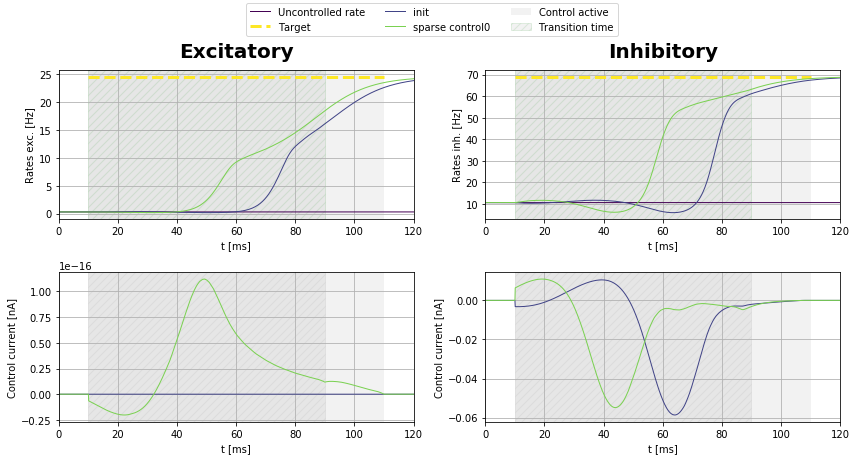

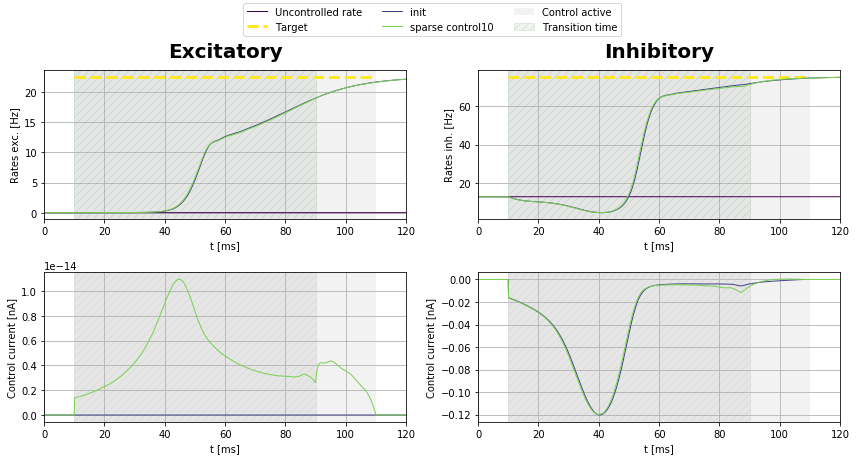

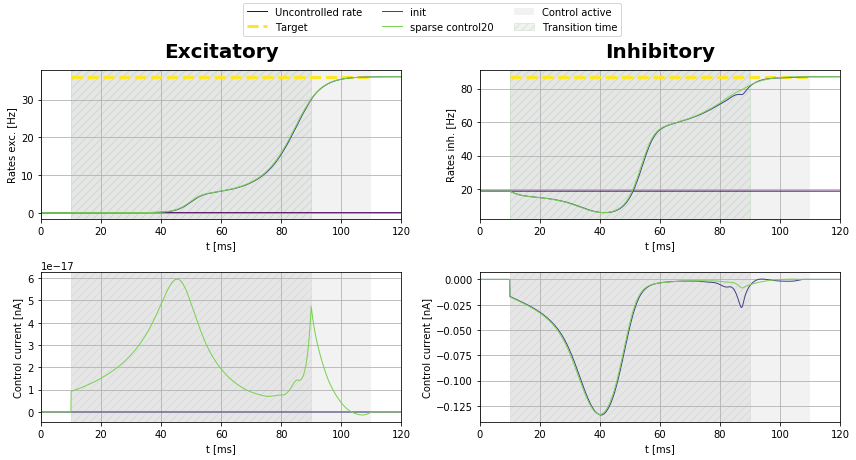

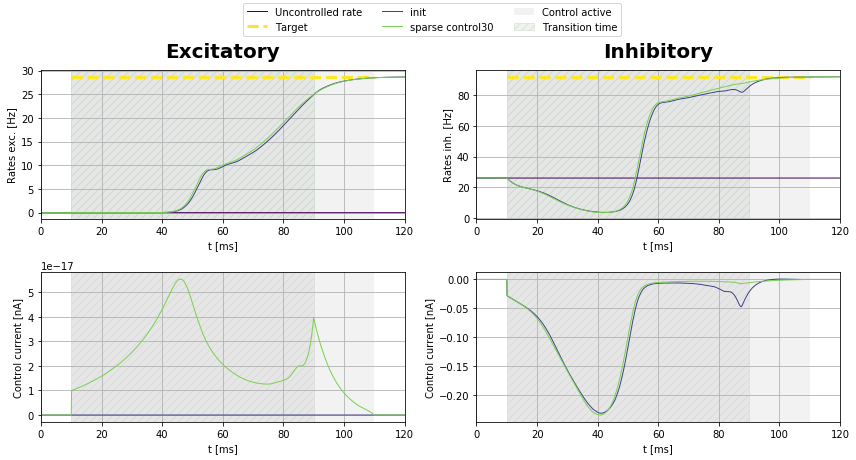

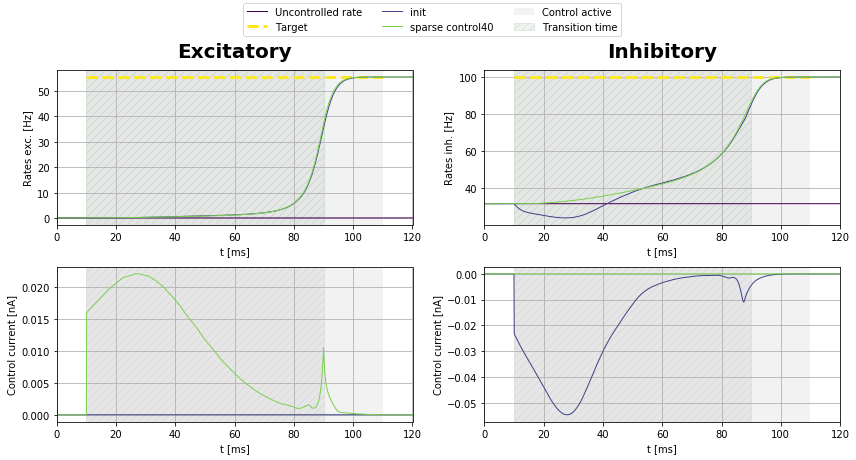

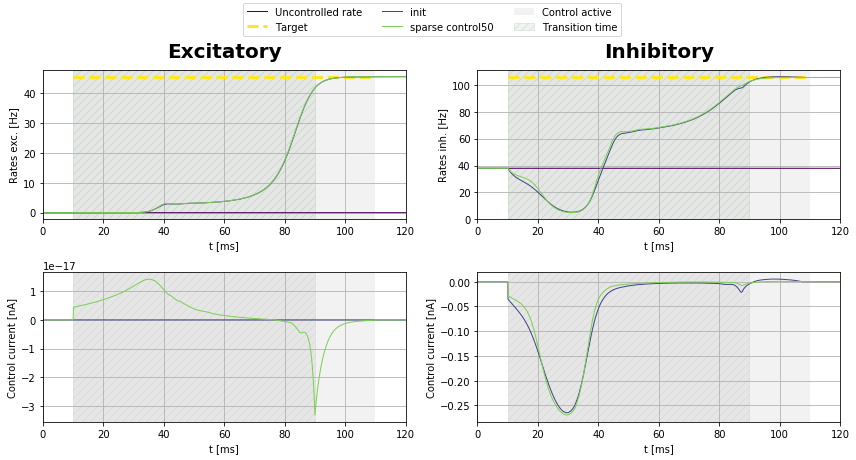

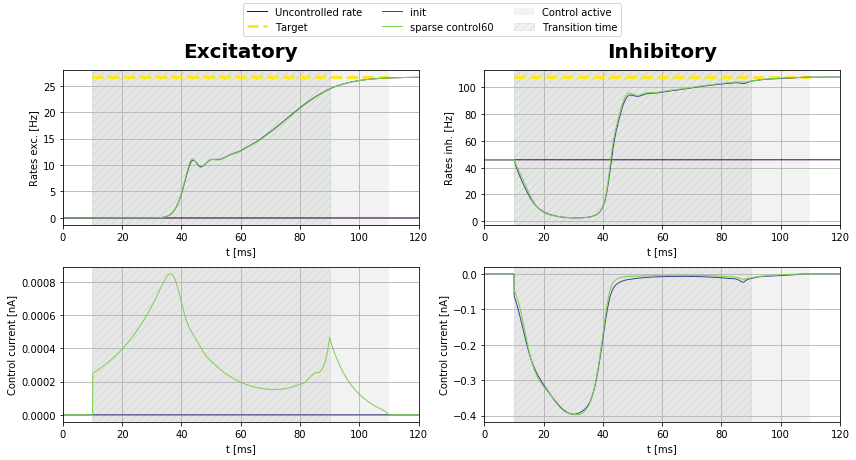

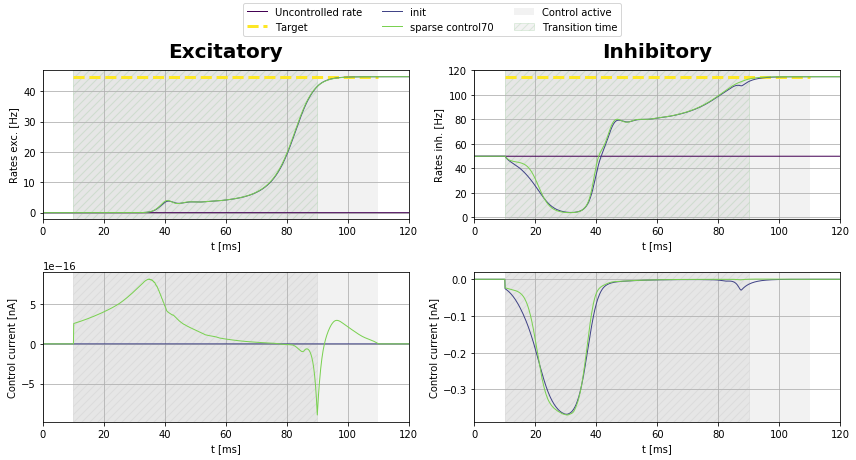

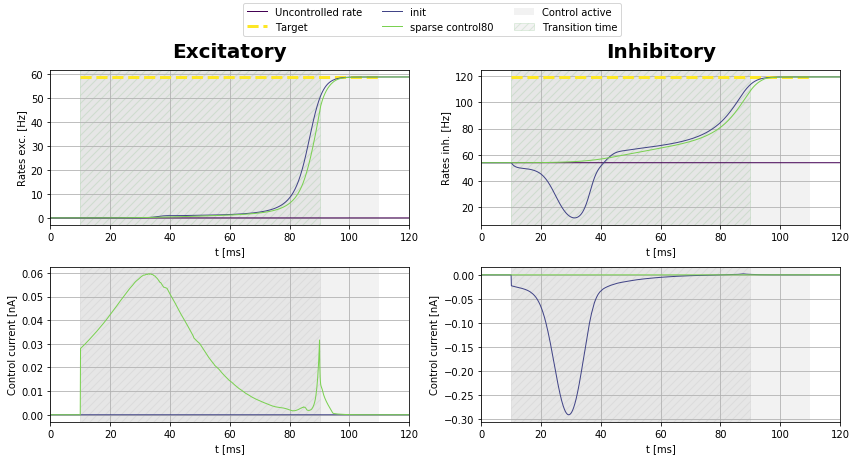

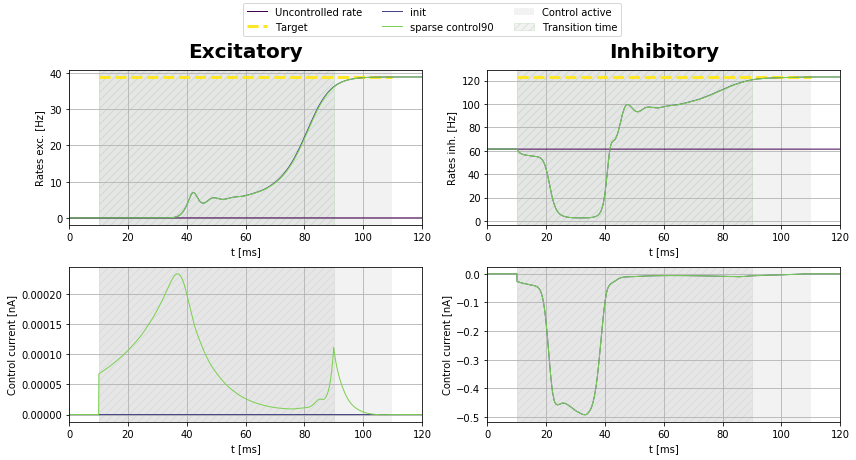

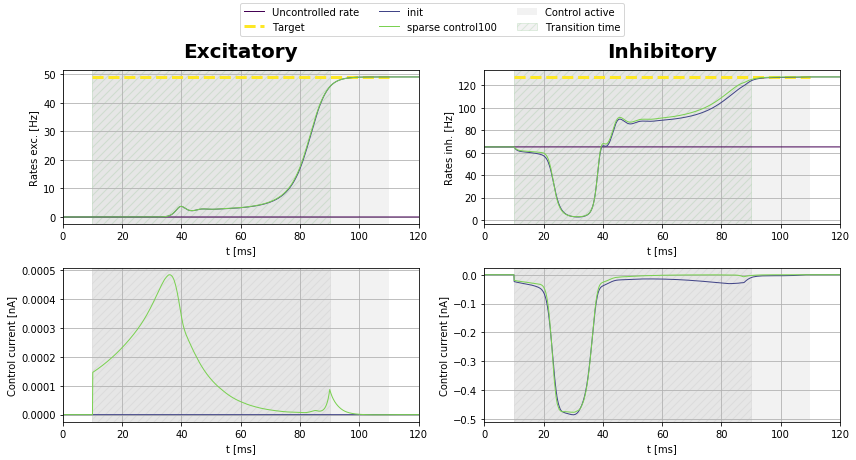

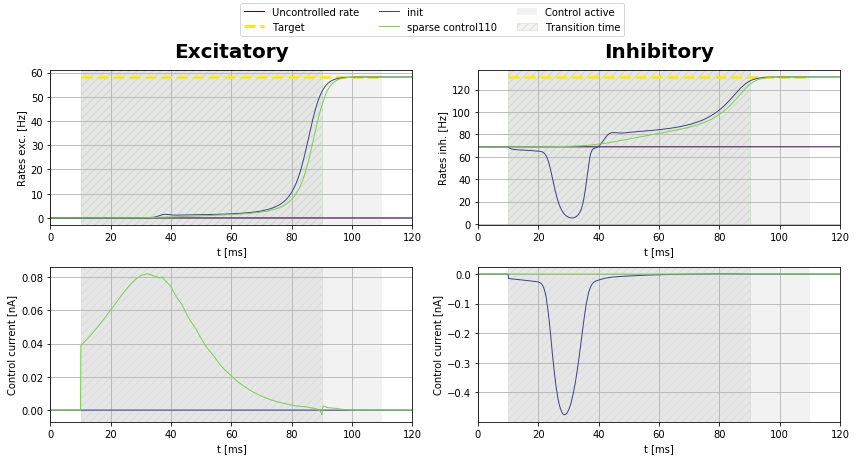

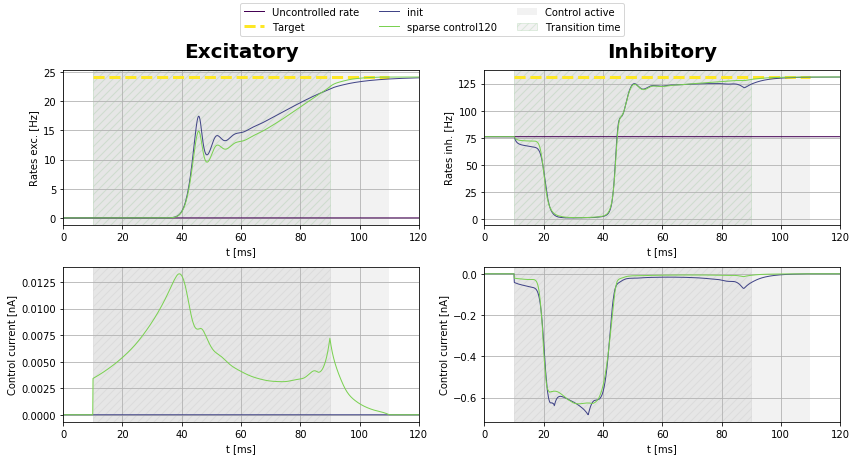

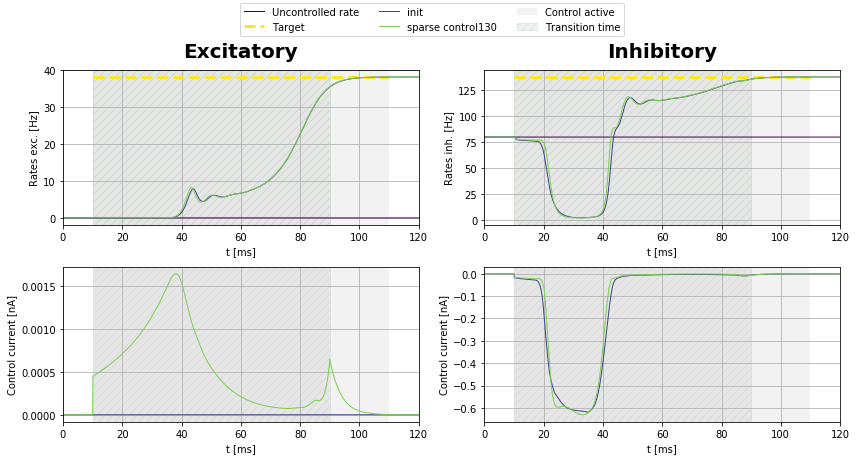

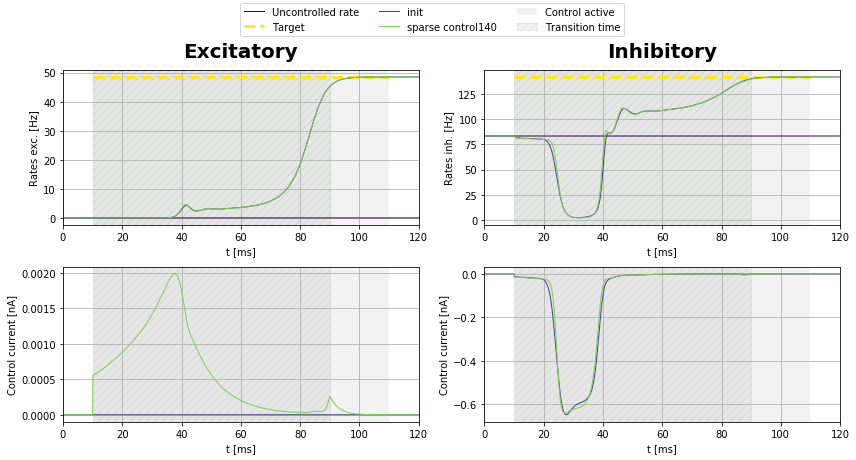

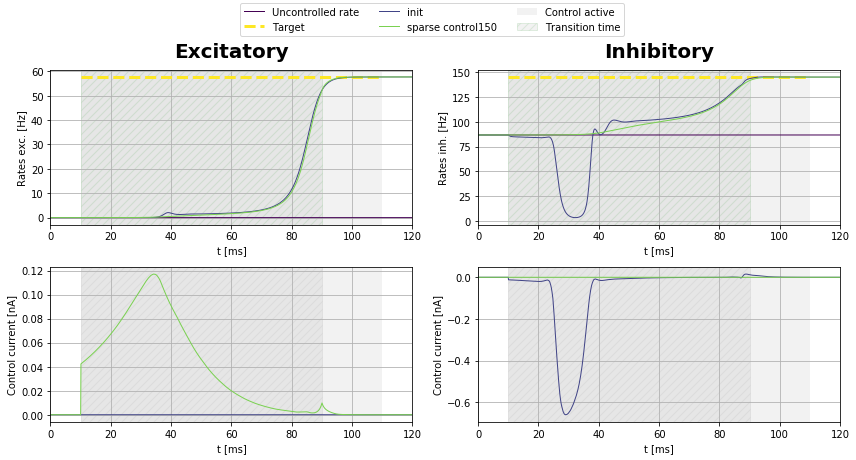

In [27]:
for i in i_range:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [34]:
factor_iteration = 10
    
for i in i_range:

    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                   + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 500 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
weight =  5169.1142138891155
set cost params:  1.0 0.0 5169.1142138891155
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5290.402181474764
Gradient descend method:  None
RUN  1 , total integrated cost =  5308.777003076524
Control only changes marginally.


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  5308.777003076524
Improved over  1  iterations in  0.17390369999998256  seconds by  -0.3473237189055851  percent.
Problem in initial value trasfer:  Vmean_exc -56.62612643343098 -56.626138257280815
-------  10 0.4000000000000001 0.40000000000000013
weight =  1908.9909477230576
set cost params:  1.0 0.0 1908.9909477230576
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  4576.795427595249
Gradient descend method:  None
RUN  1 , total integrated cost =  4583.1231570509235
Control only changes marginally.
RUN  1 , total integrated cost =  4583.1231570509235
Improved over  1  iterations in  0.17457889999991494  seconds by  -0.13825676842627388  percent.
Problem in initial value trasfer:  Vmean_exc -56.625247449489116 -56.62524061219464
-------  20 0.4500000000000001 0.4500000000000002
weight =  4517.115720133102
set cost params:  1.0 0.0 4517.115720133102
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  11701.02

ERROR:root:Problem in initial value trasfer



RUN  1 , total integrated cost =  11708.47312431359
Improved over  1  iterations in  0.17957320000004984  seconds by  -0.06361248442148337  percent.
Problem in initial value trasfer:  Vmean_exc -56.67044572943574 -56.67045129579668
-------  30 0.4250000000000001 0.5000000000000002
weight =  1488.2083605805924
set cost params:  1.0 0.0 1488.2083605805924
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7396.123747485992
Gradient descend method:  None
RUN  1 , total integrated cost =  7400.454298636458


...

1 , total integrated cost =  13074.762099871228
Control only changes marginally.
RUN  1 , total integrated cost =  13074.762099871228
Improved over  1  iterations in  0.17677420000018174  seconds by  -0.009271116915485322  percent.
Problem in initial value trasfer:  Vmean_exc -56.677241058063906 -56.67724229052458
-------  140 0.5250000000000001 0.8750000000000006
weight =  1942.0589388795213
set cost params:  1.0 0.0 1942.0589388795213
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21157.684409610723
Gradient descend method:  None
RUN  1 , total integrated cost =  21159.073702101385
Control only changes marginally.


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  21159.073702101385
Improved over  1  iterations in  0.1729205000001457  seconds by  -0.00656637306694563  percent.
Problem in initial value trasfer:  Vmean_exc -56.700674371685125 -56.70067446902705
-------  150 0.5750000000000002 0.9000000000000006
weight =  11303.207489656212
set cost params:  1.0 0.0 11303.207489656212
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  29935.76451539451
Gradient descend method:  None
RUN  1 , total integrated cost =  29945.09434595917


ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  1 , total integrated cost =  29945.09434595917
Improved over  1  iterations in  0.18198080000001937  seconds by  -0.03116616767833591  percent.
Problem in initial value trasfer:  Vmean_exc -56.703543718003765 -56.703543583609544


In [35]:
with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, costnode_0, weights_0], f)